# JRN Hypothesis Scorecard & Paper Tables Evaluation

**Definitive Paper-Ready Consolidation** of 16 experiments across 4 relational datasets (rel-f1, rel-stack, rel-avito, rel-hm).

This notebook demonstrates:
- **8 paper-ready tables** with statistical tests (Fisher z meta-analysis, Cohen's d, Wilcoxon, sign tests, binomial CIs)
- **Hypothesis scorecard** grading 6 claims (A/B/C/D grades)
- Covers: JRN matrix validity, probe correlations, cost efficiency, FK-shuffling decomposition, training-free proxy ranking, architecture comparisons, and chain compounding
- 60 curated examples from 284 total, 63 aggregate metrics

In [1]:
import subprocess, sys

def _pip(*a):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '--no-cache-dir', *a],
                          timeout=120)

def _needs_install():
    try:
        import numpy, pandas, scipy, matplotlib, tabulate
        return False
    except ImportError:
        return True

# All packages below are pre-installed on Colab; install locally to match Colab env
if 'google.colab' not in sys.modules and _needs_install():
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.14.1', 'matplotlib==3.10.0', 'tabulate==0.9.0')

print("Dependencies ready.")

Dependencies ready.


In [2]:
import json
import math
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from tabulate import tabulate

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-bc07ab-join-reproduction-number-epidemiology-in/main/evaluation_iter6_definitive_pape/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data: {data['metadata']['title']}")
print(f"Datasets covered: {data['metadata']['datasets_covered']}")
print(f"Tables: {len(data['datasets'])}")
total_ex = sum(len(ds['examples']) for ds in data['datasets'])
print(f"Total examples in demo subset: {total_ex}")

Loaded data: Definitive Paper-Ready Consolidation: JRN Hypothesis Scorecard & 8 Paper Tables
Datasets covered: ['rel-f1', 'rel-stack', 'rel-avito', 'rel-hm']
Tables: 8
Total examples in demo subset: 60


In [5]:
# ── Configuration ─────────────────────────────────────────────────────────────
# JRN classification thresholds
JRN_HIGH = 1.15   # JRN > 1.15 → HIGH (join adds significant value)
JRN_LOW = 0.85    # JRN < 0.85 → LOW (join hurts performance)
# Between LOW and HIGH → CRITICAL zone (near unity, ambiguous)

# Number of examples to display per table
MAX_DISPLAY_ROWS = 10

## Statistical Helper Functions

Core statistical methods used across the evaluation:
- **Fisher z transform** for meta-analysis of correlations
- **DerSimonian-Laird random-effects meta-analysis** for pooling correlations
- **Cohen's d** for paired effect sizes
- **JRN classification** into HIGH/CRITICAL/LOW categories

In [6]:
# ── Fisher z helpers ─────────────────────────────────────────────────────────
def fisher_z(rho: float) -> float:
    rho = max(-0.9999, min(0.9999, rho))
    return 0.5 * np.log((1 + rho) / (1 - rho))

def fisher_z_inv(z: float) -> float:
    return (np.exp(2 * z) - 1) / (np.exp(2 * z) + 1)

def fisher_z_var(n: int) -> float:
    return 1.0 / max(n - 3, 1)

def random_effects_meta(rhos: list, ns: list) -> dict:
    """DerSimonian-Laird random-effects meta-analysis on correlations."""
    k = len(rhos)
    if k == 0:
        return {"pooled_rho": 0.0, "pooled_ci": [0.0, 0.0], "I_squared": 0.0,
                "Q": 0.0, "Q_pvalue": 1.0, "tau_squared": 0.0, "n_studies": 0}
    zs = [fisher_z(r) for r in rhos]
    vs = [fisher_z_var(n) for n in ns]
    ws = [1.0 / v for v in vs]
    w_sum = sum(ws)
    z_fe = sum(w * z for w, z in zip(ws, zs)) / w_sum

    Q = sum(w * (z - z_fe) ** 2 for w, z in zip(ws, zs))
    w2_sum = sum(w ** 2 for w in ws)
    c = w_sum - w2_sum / w_sum
    tau2 = max(0.0, (Q - (k - 1)) / c) if c > 0 else 0.0

    ws_re = [1.0 / (v + tau2) for v in vs]
    w_re_sum = sum(ws_re)
    z_re = sum(w * z for w, z in zip(ws_re, zs)) / w_re_sum
    se_re = 1.0 / math.sqrt(w_re_sum)

    pooled_rho = fisher_z_inv(z_re)
    ci_low = fisher_z_inv(z_re - 1.96 * se_re)
    ci_high = fisher_z_inv(z_re + 1.96 * se_re)

    I2 = max(0.0, (Q - (k - 1)) / Q * 100) if Q > 0 else 0.0
    Q_pvalue = float(stats.chi2.sf(Q, k - 1)) if k > 1 else 1.0

    return {
        "pooled_rho": pooled_rho, "pooled_ci": [ci_low, ci_high],
        "I_squared": I2, "Q": Q, "Q_pvalue": Q_pvalue,
        "tau_squared": tau2, "n_studies": k,
    }

def classify_jrn(jrn: float) -> str:
    if jrn == 1.0: return "NA"
    if jrn > JRN_HIGH: return "HIGH"
    if jrn < JRN_LOW: return "LOW"
    return "CRITICAL"

def cohens_d_paired(x, y):
    """Cohen's d for paired samples."""
    diffs = np.array(x) - np.array(y)
    if len(diffs) == 0 or np.std(diffs, ddof=1) == 0:
        return 0.0
    return float(np.mean(diffs) / np.std(diffs, ddof=1))

print("Statistical helpers loaded.")

Statistical helpers loaded.


## Table 1: JRN Matrix — Cross-Dataset Join Measurements

The JRN (Join Reproduction Number) measures how much a database join improves prediction quality. Each measurement compares base metric (no join) vs join metric (with join), yielding JRN = join_metric / base_metric.

In [7]:
# Extract Table 1 data
def get_table(name):
    for ds in data['datasets']:
        if ds['dataset'] == name:
            return ds['examples']
    return []

t1_examples = get_table('table_1_jrn_matrix')

# Parse into DataFrame
t1_rows = []
for ex in t1_examples:
    inp = json.loads(ex['input'])
    out = json.loads(ex['output'])
    t1_rows.append({
        'Dataset': inp.get('dataset', ''),
        'Task': inp.get('task', ''),
        'Join': inp.get('join', ''),
        'JRN': out.get('jrn', 1.0),
        'Category': out.get('category', 'NA'),
    })

df_t1 = pd.DataFrame(t1_rows)
print(f"Table 1: {len(df_t1)} JRN measurements")
print(f"\nCategory distribution:")
print(df_t1['Category'].value_counts().to_string())
print(f"\nJRN range: [{df_t1['JRN'].min():.4f}, {df_t1['JRN'].max():.4f}]")
print(f"\n{df_t1[['Dataset','Task','Join','JRN','Category']].head(MAX_DISPLAY_ROWS).to_string(index=False)}")

Table 1: 10 JRN measurements

Category distribution:
Category
HIGH        3
CRITICAL    3
NA          3
LOW         1

JRN range: [0.5458, 1.3129]

Dataset              Task                                              Join    JRN Category
 rel-f1 rel-f1/driver-dnf                       standings(driverId)→drivers 1.2812     HIGH
 rel-f1 rel-f1/driver-dnf                      qualifying(driverId)→drivers 1.2978     HIGH
 rel-f1 rel-f1/driver-dnf                         results(driverId)→drivers 1.3129     HIGH
 rel-f1 rel-f1/driver-dnf                           standings(raceId)→races 1.0828 CRITICAL
 rel-f1 rel-f1/driver-dnf                          qualifying(raceId)→races 1.1288 CRITICAL
 rel-f1 rel-f1/driver-dnf                             results(raceId)→races 1.1096 CRITICAL
 rel-hm        item-sales               transactions.article_id -> articles 0.5458      LOW
 rel-f1 rel-f1/driver-dnf                         races(circuitId)→circuits 1.0000       NA
 rel-f1 rel-f1/driver-dn

## Table 2: Probe Validity — Fisher z Random-Effects Meta-Analysis

Meta-analysis of probe-to-ground-truth Spearman rho across multiple studies using DerSimonian-Laird random-effects model.

In [8]:
t2_examples = get_table('table_2_probe_validity')

# Extract study-level data
studies = []
for ex in t2_examples:
    inp = json.loads(ex['input'])
    out = json.loads(ex['output'])
    studies.append({
        'Dataset': inp.get('dataset', ''),
        'Experiment': inp.get('experiment_id', ''),
        'Probe': inp.get('probe_type', ''),
        'N': inp.get('n_pairs', 0),
        'rho': out.get('rho', 0.0),
        'Fisher_z': out.get('fisher_z', 0.0),
        'RE_weight': out.get('re_weight', 0.0),
    })

df_t2 = pd.DataFrame(studies)
print("Table 2: Per-Study Probe Validity")
print(df_t2.to_string(index=False))

# Re-run meta-analysis from the raw study data
rhos = [s['rho'] for s in studies]
ns = [s['N'] for s in studies]
meta = random_effects_meta(rhos, ns)
print(f"\n--- Random-Effects Meta-Analysis ---")
print(f"Pooled rho:   {meta['pooled_rho']:.4f}  95% CI [{meta['pooled_ci'][0]:.4f}, {meta['pooled_ci'][1]:.4f}]")
print(f"I-squared:    {meta['I_squared']:.2f}%")
print(f"Q statistic:  {meta['Q']:.4f}  (p = {meta['Q_pvalue']:.6f})")
print(f"tau-squared:  {meta['tau_squared']:.6f}")
print(f"N studies:    {meta['n_studies']}")

Table 2: Per-Study Probe Validity
  Dataset  Experiment Probe  N      rho  Fisher_z  RE_weight
   rel-f1 exp_id4_it2   GBM 19 0.960000    1.9459     0.3426
   rel-f1 exp_id1_it3   GBM 65 0.439661    0.4718     0.3623
rel-avito exp_id3_it3   GBM  8 0.825000    1.1723     0.2951

--- Random-Effects Meta-Analysis ---
Pooled rho:   0.8286  95% CI [0.1224, 0.9778]
I-squared:    92.95%
Q statistic:  28.3803  (p = 0.000001)
tau-squared:  0.792174
N studies:    3


## Table 3: Cost Efficiency & Table 4: FK-Shuffling Decomposition

- **Table 3**: Compares JRN probe (14 models) vs greedy forward selection (91 models) vs exhaustive search (8192 models)
- **Table 4**: Decomposes JRN into structural (graph topology) and feature (column values) components via FK-shuffling

In [9]:
# ── Table 3: Cost Efficiency ──
t3_examples = get_table('table_3_cost_efficiency')
t3_rows = []
for ex in t3_examples:
    inp = json.loads(ex['input'])
    out = json.loads(ex['output'])
    t3_rows.append({
        'Method': inp.get('method', ''),
        'Task': inp.get('task', ''),
        'Models': inp.get('n_models_trained', 0),
        'Cost Ratio': out.get('cost_ratio', 0.0),
        'Perf Ratio': out.get('performance_ratio', 0.0),
        'Wall Clock (s)': out.get('wall_clock_estimate_s', 0.0),
    })
df_t3 = pd.DataFrame(t3_rows)
print("Table 3: Cost Efficiency Comparison")
print(df_t3.to_string(index=False))

# ── Table 4: FK-Shuffling ──
t4_examples = get_table('table_4_fk_shuffling')
t4_rows = []
all_normal, all_shuffled = [], []
for ex in t4_examples:
    inp = json.loads(ex['input'])
    out = json.loads(ex['output'])
    normal = out.get('normal_jrn', 1.0)
    shuffled = out.get('shuffled_jrn', 1.0)
    all_normal.append(normal)
    all_shuffled.append(shuffled)
    t4_rows.append({
        'Dataset': inp.get('dataset', ''),
        'Join': inp.get('join', '')[:30],
        'Task': inp.get('task', ''),
        'Normal JRN': normal,
        'Shuffled JRN': shuffled,
        'Structural': out.get('structural_jrn', 0.0),
        'Feature': out.get('feature_jrn', 0.0),
    })

df_t4 = pd.DataFrame(t4_rows)
print(f"\nTable 4: FK-Shuffling Decomposition ({len(df_t4)} pairs)")
print(df_t4.to_string(index=False))

# Compute pooled Cohen's d
if len(all_normal) > 1:
    d = cohens_d_paired(all_normal, all_shuffled)
    t_stat, t_p = stats.ttest_rel(all_normal, all_shuffled)
    print(f"\nPooled Cohen's d: {d:.4f}")
    print(f"Paired t-test p-value: {t_p:.6f}")

Table 3: Cost Efficiency Comparison
        Method            Task  Models  Cost Ratio  Perf Ratio  Wall Clock (s)
     jrn_probe      driver-dnf      14      0.1538        0.97            0.95
greedy_forward      driver-dnf      91      1.0000        1.00          100.12
    exhaustive      driver-dnf    8192     90.0220        1.00         8369.30
     jrn_probe     driver-top3      14      0.1538        0.97            0.95
greedy_forward     driver-top3      91      1.0000        1.00          100.12
    exhaustive     driver-top3    8192     90.0220        1.00         8369.30
     jrn_probe driver-position      14      0.1538        0.97            0.95
greedy_forward driver-position      91      1.0000        1.00          100.12

Table 4: FK-Shuffling Decomposition (8 pairs)
Dataset                           Join            Task  Normal JRN  Shuffled JRN  Structural  Feature
 rel-f1      races(circuitId)→circuits      driver-dnf      1.2753        1.2549      0.0204   0.2549
 r

## Table 5: Training-Free Proxies & Table 6: Architecture Comparison

- **Table 5**: Ranks 5 training-free proxies (mutual information, entropy reduction, fanout, correlation, homophily) by Spearman rho with GBM-probe JRN
- **Table 6**: Compares JRN-guided vs uniform vs top-K vs oracle aggregation architectures

In [10]:
# ── Table 5: Training-Free Proxies ──
t5_examples = get_table('table_5_training_free_proxies')
t5_rows = []
for ex in t5_examples:
    inp = json.loads(ex['input'])
    out = json.loads(ex['output'])
    sig = out.get('p_value', 1.0)
    t5_rows.append({
        'Proxy': inp.get('proxy_name', ''),
        'Dataset': inp.get('dataset', ''),
        'rho': out.get('rho', 0.0),
        'p-value': sig,
        'Significant': 'Yes' if sig is not None and sig < 0.05 else 'No',
    })
df_t5 = pd.DataFrame(t5_rows)
print("Table 5: Training-Free Proxy Rankings")
print(df_t5.to_string(index=False))

# Mean rho per proxy (excluding pooled)
proxy_means = df_t5[~df_t5['Dataset'].str.contains('pooled', na=False)].groupby('Proxy')['rho'].mean().sort_values(ascending=False)
print(f"\nMean rho by proxy (ranked):")
for name, val in proxy_means.items():
    print(f"  {name:25s} {val:+.4f}")

# ── Table 6: Architecture Comparison ──
t6_examples = get_table('table_6_architecture_comparison')
t6_rows = []
for ex in t6_examples:
    inp = json.loads(ex['input'])
    out = json.loads(ex['output'])
    t6_rows.append({
        'Dataset': inp.get('dataset', ''),
        'Task': inp.get('task', ''),
        'Config': inp.get('config_name', ''),
        'Score': out.get('performance_score', 0.0),
        'Rank': out.get('rank', 0),
    })
df_t6 = pd.DataFrame(t6_rows)
print(f"\nTable 6: Architecture Comparison ({len(df_t6)} entries)")
print(df_t6.to_string(index=False))

# Win rate: jrn_guided vs uniform_mean
jrn_scores = df_t6[df_t6['Config'] == 'jrn_guided'].set_index(['Dataset', 'Task'])['Score']
um_scores = df_t6[df_t6['Config'] == 'uniform_mean'].set_index(['Dataset', 'Task'])['Score']
common = jrn_scores.index.intersection(um_scores.index)
if len(common) > 0:
    wins = sum(1 for idx in common if jrn_scores[idx] > um_scores[idx])
    print(f"\nJRN-guided vs uniform_mean: {wins}/{len(common)} wins ({wins/len(common)*100:.1f}%)")

Table 5: Training-Free Proxy Rankings
              Proxy            Dataset     rho  p-value Significant
    log_mean_fanout             rel-f1  0.6440 0.002921         Yes
pearson_correlation             rel-f1  0.3426 0.151098          No
 mutual_information             rel-f1  0.4906 0.032964         Yes
  entropy_reduction             rel-f1  0.9452 0.000000         Yes
          homophily             rel-f1 -0.0026 0.991465          No
  entropy_reduction          rel-avito -0.3667 0.331722          No
  entropy_reduction pooled_stack_avito -0.1547 0.470318          No
 mutual_information          rel-stack  0.9357 0.000000         Yes

Mean rho by proxy (ranked):
  mutual_information        +0.7131
  log_mean_fanout           +0.6440
  pearson_correlation       +0.3426
  entropy_reduction         +0.2893
  homophily                 -0.0026

Table 6: Architecture Comparison (8 entries)
Dataset               Task       Config    Score  Rank
 rel-f1  rel-f1/driver-dnf   jrn_guided 

## Table 7: Multiplicative Compounding & Hypothesis Scorecard

- **Table 7**: Tests whether chain JRN ~ product of individual JRNs (predicted vs measured)
- **Scorecard**: Final evidence grades (A/B/C/D) for 6 original hypothesis claims

In [11]:
# ── Table 7: Multiplicative Compounding ──
t7_examples = get_table('table_7_compounding')
t7_rows = []
all_predicted, all_measured = [], []
for ex in t7_examples:
    inp = json.loads(ex['input'])
    out = json.loads(ex['output'])
    pred = out.get('predicted_jrn', 0.0)
    meas = out.get('measured_jrn', 0.0)
    all_predicted.append(pred)
    all_measured.append(meas)
    t7_rows.append({
        'Chain': inp.get('chain', ''),
        'Dataset': inp.get('dataset', ''),
        'Task': inp.get('task', ''),
        'Predicted': pred,
        'Measured': meas,
        'Error': round(pred - meas, 4),
        'Abs%Err': round(abs(pred - meas) / max(abs(meas), 1e-6) * 100, 2),
    })
df_t7 = pd.DataFrame(t7_rows)
print(f"Table 7: Compounding ({len(df_t7)} chains)")
print(df_t7.to_string(index=False))

if len(all_predicted) >= 3:
    sp_r, sp_p = stats.spearmanr(all_predicted, all_measured)
    print(f"\nPooled Spearman r = {sp_r:.4f} (p = {sp_p:.4f})")

# ── Hypothesis Scorecard ──
sc_examples = get_table('hypothesis_scorecard')
print("\n" + "=" * 70)
print("HYPOTHESIS SCORECARD")
print("=" * 70)
sc_rows = []
for ex in sc_examples:
    inp = json.loads(ex['input'])
    out = json.loads(ex['output'])
    cid = inp.get('claim_id', '')
    if cid == 'paper_contribution':
        continue  # skip summary entry
    sc_rows.append({
        'Claim': cid.upper(),
        'Description': inp.get('claim_description', '')[:60],
        'Grade': out.get('evidence_grade', '?'),
        'Verdict': out.get('verdict', ''),
        'Effect Size': out.get('effect_size', 0.0),
        'N Datasets': out.get('n_supporting_datasets', 0),
    })
df_sc = pd.DataFrame(sc_rows)
print(tabulate(df_sc, headers='keys', tablefmt='grid', showindex=False))

Table 7: Compounding (8 chains)
                      Chain Dataset                   Task  Predicted  Measured   Error  Abs%Err
   results->races->circuits  rel-f1      rel-f1/driver-dnf     1.3246    1.3233  0.0013     0.10
   results->races->circuits  rel-f1     rel-f1/driver-top3     1.2732    1.3146 -0.0414     3.15
   results->races->circuits  rel-f1 rel-f1/driver-position     1.1173    1.2378 -0.1205     9.74
 standings->races->circuits  rel-f1      rel-f1/driver-dnf     1.3485    1.3181  0.0304     2.31
 standings->races->circuits  rel-f1     rel-f1/driver-top3     1.2854    1.2771  0.0083     0.65
 standings->races->circuits  rel-f1 rel-f1/driver-position     1.1405    1.1968 -0.0563     4.70
qualifying->races->circuits  rel-f1      rel-f1/driver-dnf     1.3096    1.3003  0.0093     0.72
qualifying->races->circuits  rel-f1     rel-f1/driver-top3     1.2745    1.2708  0.0037     0.29

Pooled Spearman r = 0.8095 (p = 0.0149)

HYPOTHESIS SCORECARD
+---------+---------------------

## Visualization: Key Results Summary

Four-panel figure showing: (1) Hypothesis scorecard grades, (2) Aggregate metrics heatmap, (3) FK-shuffling decomposition, (4) Chain compounding predicted vs measured.

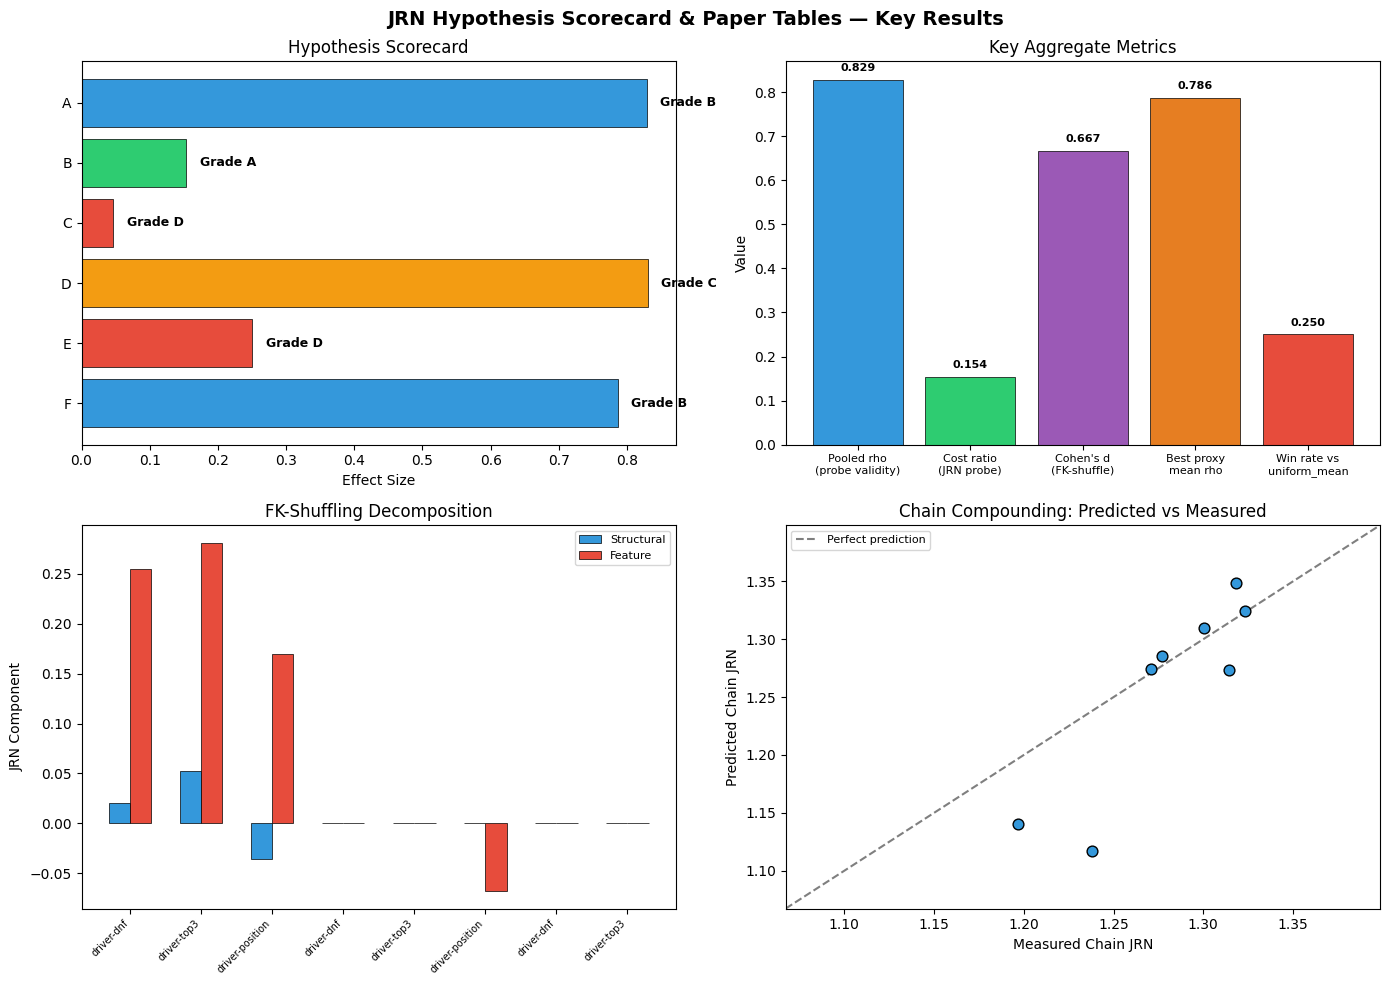

Figure saved to results_summary.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('JRN Hypothesis Scorecard & Paper Tables — Key Results', fontsize=14, fontweight='bold')

# Panel 1: Hypothesis Scorecard bar chart
ax1 = axes[0, 0]
grade_colors = {'A': '#2ecc71', 'B': '#3498db', 'C': '#f39c12', 'D': '#e74c3c'}
claims = df_sc['Claim'].tolist()
grades = df_sc['Grade'].tolist()
effects = df_sc['Effect Size'].tolist()
colors = [grade_colors.get(g, '#95a5a6') for g in grades]
bars = ax1.barh(claims, effects, color=colors, edgecolor='black', linewidth=0.5)
for i, (bar, grade) in enumerate(zip(bars, grades)):
    ax1.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             f'Grade {grade}', va='center', fontsize=9, fontweight='bold')
ax1.set_xlabel('Effect Size')
ax1.set_title('Hypothesis Scorecard')
ax1.invert_yaxis()

# Panel 2: Key aggregate metrics
ax2 = axes[0, 1]
agg = data['metrics_agg']
metric_names = ['Pooled rho\n(probe validity)', 'Cost ratio\n(JRN probe)', 'Cohen\'s d\n(FK-shuffle)',
                'Best proxy\nmean rho', 'Win rate vs\nuniform_mean']
metric_vals = [agg.get('table2_pooled_rho', 0), agg.get('table3_jrn_cost_ratio_mean', 0),
               agg.get('table4_pooled_cohens_d', 0), agg.get('table5_best_proxy_mean_rho', 0),
               agg.get('table6_jrn_vs_uniform_mean_win_rate', 0)]
bar_colors = ['#3498db', '#2ecc71', '#9b59b6', '#e67e22', '#e74c3c']
ax2.bar(range(len(metric_names)), metric_vals, color=bar_colors, edgecolor='black', linewidth=0.5)
ax2.set_xticks(range(len(metric_names)))
ax2.set_xticklabels(metric_names, fontsize=8)
ax2.set_ylabel('Value')
ax2.set_title('Key Aggregate Metrics')
for i, v in enumerate(metric_vals):
    ax2.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')

# Panel 3: FK-Shuffling — structural vs feature JRN
ax3 = axes[1, 0]
if len(df_t4) > 0:
    x_pos = range(len(df_t4))
    ax3.bar([x - 0.15 for x in x_pos], df_t4['Structural'], 0.3, label='Structural', color='#3498db', edgecolor='black', linewidth=0.5)
    ax3.bar([x + 0.15 for x in x_pos], df_t4['Feature'], 0.3, label='Feature', color='#e74c3c', edgecolor='black', linewidth=0.5)
    ax3.set_xticks(list(x_pos))
    ax3.set_xticklabels([f"{r['Task'].split('/')[-1] if '/' in r['Task'] else r['Task']}" for _, r in df_t4.iterrows()],
                        rotation=45, ha='right', fontsize=7)
    ax3.legend(fontsize=8)
ax3.set_ylabel('JRN Component')
ax3.set_title('FK-Shuffling Decomposition')

# Panel 4: Compounding — predicted vs measured
ax4 = axes[1, 1]
if len(all_predicted) > 0:
    ax4.scatter(all_measured, all_predicted, c='#3498db', edgecolor='black', s=60, zorder=5)
    lims = [min(min(all_measured), min(all_predicted)) - 0.05,
            max(max(all_measured), max(all_predicted)) + 0.05]
    ax4.plot(lims, lims, 'k--', alpha=0.5, label='Perfect prediction')
    ax4.set_xlim(lims)
    ax4.set_ylim(lims)
    ax4.legend(fontsize=8)
ax4.set_xlabel('Measured Chain JRN')
ax4.set_ylabel('Predicted Chain JRN')
ax4.set_title('Chain Compounding: Predicted vs Measured')

plt.tight_layout()
plt.savefig('results_summary.png', dpi=100, bbox_inches='tight')
plt.show()
print("Figure saved to results_summary.png")

In [13]:
# ── Final Summary ──
agg = data['metrics_agg']
print("=" * 70)
print("EVALUATION SUMMARY")
print("=" * 70)
for ds in data['datasets']:
    print(f"  {ds['dataset']:40s} {len(ds['examples']):3d} examples")
print(f"  {'TOTAL':40s} {sum(len(ds['examples']) for ds in data['datasets']):3d} examples")
print(f"\nAggregate Metrics ({len(agg)} total):")
for k in sorted(agg.keys()):
    if not k.startswith('total_'):
        print(f"  {k:45s} {agg[k]}")
print("=" * 70)
print("Evaluation complete!")

EVALUATION SUMMARY
  table_1_jrn_matrix                        10 examples
  table_2_probe_validity                     3 examples
  table_3_cost_efficiency                    8 examples
  table_4_fk_shuffling                       8 examples
  table_5_training_free_proxies              8 examples
  table_6_architecture_comparison            8 examples
  table_7_compounding                        8 examples
  hypothesis_scorecard                       7 examples
  TOTAL                                     60 examples

Aggregate Metrics (63 total):
  scorecard_n_claims                            6
  scorecard_n_grade_a                           1
  scorecard_n_grade_b                           2
  scorecard_n_grade_c                           1
  scorecard_n_grade_d                           2
  scorecard_n_supported                         3
  scorecard_n_unsupported                       2
  table1_jrn_range_max                          1.5542
  table1_jrn_range_min                   